## Sensor Degradation Analysis

#### This notebook investigates how sensor measurements change as the engines progress through their operating cycles.

#### The goal is to identify sensors that contain meaningful information about engine degradation and Remaining Useful Life (RUL).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columns = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    "CMAPSSData/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

train["RUL"] = (
    train.groupby("engine_id")["cycle"]
    .transform("max") - train["cycle"]
)

train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [2]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

unique_counts = train[sensor_cols].nunique().sort_values()

unique_counts

sensor_1        1
sensor_5        1
sensor_16       1
sensor_10       1
sensor_19       1
sensor_18       1
sensor_6        2
sensor_17      13
sensor_8       53
sensor_13      56
sensor_20     120
sensor_11     159
sensor_2      310
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

In [3]:
constant_sensors = unique_counts[unique_counts == 1].index.tolist()

constant_sensors

['sensor_1', 'sensor_5', 'sensor_16', 'sensor_10', 'sensor_19', 'sensor_18']

In [4]:
variable_sensors = [
    sensor for sensor in sensor_cols
    if sensor not in constant_sensors
]

print("Constant sensors:", constant_sensors)
print("Number of constant sensors:", len(constant_sensors))
print("Number of variable sensors:", len(variable_sensors))

Constant sensors: ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_10', 'sensor_19', 'sensor_18']
Number of constant sensors: 6
Number of variable sensors: 15


In [5]:
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train_clean = train.drop(columns=constant_sensors)

train_clean.shape

(20631, 21)

In [6]:
train_clean.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [7]:
train_clean.columns

Index(['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2',
       'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'RUL'],
      dtype='str')

In [8]:
feature_sensors = [
    col for col in train_clean.columns
    if col.startswith("sensor_")
]

feature_sensors

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

In [9]:
len(feature_sensors)

15

In [10]:
feature_data = train_clean.copy()

In [11]:
#Create the features
for sensor in feature_sensors:

    # Recent 5-cycle average
    feature_data[f"{sensor}_rolling_mean"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    )

    # Recent 5-cycle variability
    feature_data[f"{sensor}_rolling_std"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(lambda x: x.rolling(window=5, min_periods=1).std())
    )

    # Change from previous cycle
    feature_data[f"{sensor}_delta"] = (
        feature_data.groupby("engine_id")[sensor]
        .diff()
    )

In [12]:
feature_data.shape

(20631, 66)

In [13]:
# Look at one sensor
feature_data[
    [
        "engine_id",
        "cycle",
        "sensor_2",
        "sensor_2_rolling_mean",
        "sensor_2_rolling_std",
        "sensor_2_delta",
        "RUL"
    ]
].head(10)

,engine_id,cycle,sensor_2,sensor_2_rolling_mean,sensor_2_rolling_std,sensor_2_delta,RUL
0,1,1,641.82,641.820000,NaN,NaN,191
1,1,2,642.15,641.985000,0.233345,0.33,190
2,1,3,642.35,642.106667,0.267644,0.20,189
3,1,4,642.35,642.167500,0.250117,0.00,188
4,1,5,642.37,642.208000,0.234776,0.02,187
5,1,6,642.10,642.264000,0.128374,-0.27,186
6,1,7,642.48,642.330000,0.139463,0.38,185
7,1,8,642.56,642.372000,0.174270,0.08,184
8,1,9,642.12,642.326000,0.208519,-0.44,183
9,1,10,641.71,642.194000,0.340705,-0.41,182


In [14]:
# Train--Validation Split
engine_ids = feature_data["engine_id"].unique()

len(engine_ids)

100

In [15]:
from sklearn.model_selection import train_test_split

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

In [16]:
train_data = feature_data[
    feature_data["engine_id"].isin(train_engines)
].copy()

val_data = feature_data[
    feature_data["engine_id"].isin(val_engines)
].copy()

In [17]:
print("Training engines:", train_data["engine_id"].nunique())
print("Validation engines:", val_data["engine_id"].nunique())

print("Training shape:", train_data.shape)
print("Validation shape:", val_data.shape)

Training engines: 80
Validation engines: 20
Training shape: (16561, 66)
Validation shape: (4070, 66)


In [18]:
# Create X and Y 
# X--> information given to the model
# Y--> RUL that the model must predict
# Separate features and target

X_train = train_data.drop(columns=["RUL", "engine_id"])
y_train = train_data["RUL"]

X_val = val_data.drop(columns=["RUL", "engine_id"])
y_val = val_data["RUL"]

In [19]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (16561, 64)
y_train shape: (16561,)
X_val shape: (4070, 64)
y_val shape: (4070,)


In [20]:
# Checking features for the NaN values, especially because we created  rolling standard deviation and delta features
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in X_val:", X_val.isnull().sum().sum())

NaN values in X_train: 2400
NaN values in X_val: 600


In [21]:
# Fill missing values with 0, created by feature engineering 
# Fill missing values created by feature engineering

X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

In [22]:
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in X_val:", X_val.isnull().sum().sum())

NaN values in X_train: 0
NaN values in X_val: 0


In [23]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (16561, 64)
X_val: (4070, 64)
y_train: (16561,)
y_val: (4070,)


#### Train our first RUL model, Since RUL is a continuous number, this is a regression problem

In [29]:
# Import the model
from sklearn.ensemble import RandomForestRegressor

In [30]:
# Create the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [31]:
# Train it,,it basically learned patterns from the 80 training engines
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [32]:
# Make validation predictions 
y_pred = rf_model.predict(X_val)

In [33]:
print("Actual RUL:   ", y_val.values[:10])
print("Predicted RUL:", y_pred[:10])

Actual RUL:    [191 190 189 188 187 186 185 184 183 182]
Predicted RUL: [227.825 245.66  231.375 214.89  217.415 211.88  209.84  190.685 187.68
 183.99 ]


In [35]:
# Checking errors in our predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 23.528966830466832
MSE : 1016.9209355958232
RMSE: 31.889197788527436
R²  : 0.7640649224299252


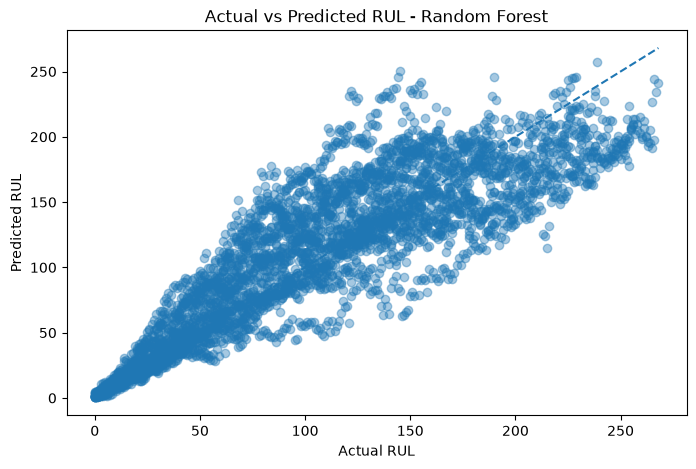

In [36]:
# Actual Vs Predicted RUL
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_val, y_pred, alpha=0.4)

# Perfect prediction line
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL - Random Forest")

plt.show()

# Dashed line represents prefect prediction

## Observation

#### The Actual vs Predicted RUL plot shows a clear positive relationship between actual and predicted RUL values. Many predictions are reasonably close to the perfect-prediction line, indicating that the Random Forest has learned useful relationships between the engineered sensor features and RUL.

#### However, there is noticeable spread around the diagonal line, particularly at higher RUL values, indicating that the model still makes prediction errors.

In [38]:
# Feature Importance-->This will give us 15 most important features 
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

cycle                     0.528291
sensor_4_rolling_mean     0.072582
sensor_15_rolling_mean    0.064788
sensor_11_rolling_mean    0.046764
sensor_9_rolling_mean     0.029557
sensor_14_rolling_mean    0.028689
sensor_12_rolling_mean    0.015035
sensor_7_rolling_mean     0.012586
sensor_8_rolling_mean     0.011125
sensor_21_rolling_mean    0.010080
sensor_13_rolling_mean    0.009751
sensor_2_rolling_mean     0.009246
sensor_3_rolling_mean     0.008451
sensor_20_rolling_mean    0.007535
sensor_11_rolling_std     0.007194
dtype: float64

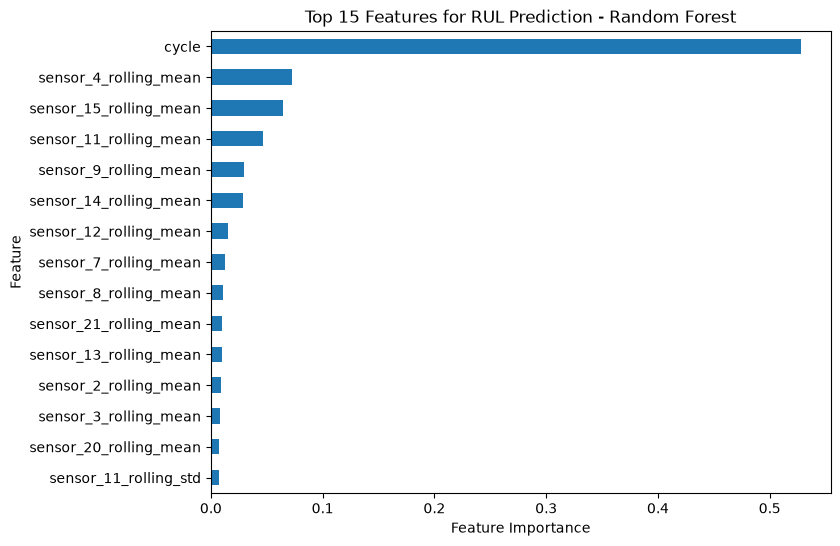

In [39]:
plt.figure(figsize=(8, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for RUL Prediction - Random Forest")

plt.show()

## Observation

#### The feature-importance analysis shows that `cycle` is the most important feature for RUL prediction in the Random Forest model. Several rolling-mean sensor features also have relatively high importance, indicating that recent sensor behavior provides useful information for estimating RUL.

#### The result does not mean that these features cause degradation; it indicates that the model found them useful for making predictions.

## Observation

#### The Random Forest feature-importance analysis shows that `cycle` is the most important feature for RUL prediction, with an importance of approximately 0.53. This is expected because RUL is directly related to the remaining number of cycles in an engine's lifetime.

#### Several rolling-mean sensor features, particularly `sensor_4`, `sensor_15`, `sensor_11`, `sensor_9`, and `sensor_14`, also show relatively high importance. This indicates that the recent operating level of these sensors contains useful information for RUL prediction.

#### `rolling_std` and other engineered features have lower importance among the top 15, but they were still available to the model during training.